# Algorithmic Bias Analysis: COMPAS Recidivism Risk Scores

## Problem

This project analyzes whether COMPAS risk scores show evidence of bias across racial groups.

COMPAS is a risk assessment tool used in criminal justice settings to estimate a defendant's likelihood of reoffending. Because these scores can influence real-world decisions, it is important to evaluate whether prediction errors are distributed fairly across groups.

---
----

## Data Overview

**Purpose:** Understand the structure and scope of the dataset before analyzing bias.

This dataset contains criminal defendant records, including demographic information, COMPAS risk scores, and outcomes related to recidivism.

Each row represents an individual, and the dataset includes variables such as age, race, sex, prior offenses, and COMPAS risk scores.

The goal is to explore how these variables relate to predictions and whether errors differ across groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

compas = pd.read_csv("../data/compas-scores-two-years.csv")

print(compas.shape)
compas.head()

(7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [2]:
compas.info()
compas.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   object 
 2   first                    7214 non-null   object 
 3   last                     7214 non-null   object 
 4   compas_screening_date    7214 non-null   object 
 5   sex                      7214 non-null   object 
 6   dob                      7214 non-null   object 
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   object 
 9   race                     7214 non-null   object 
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count            

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,6907.000000,7192.000000,7214.000000,2316.000000,0.0,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000
mean,5501.255753,34.817993,0.067230,4.509565,0.090934,0.109371,3.472415,3.304763,57.731368,0.481148,20.269430,NaN,0.113529,4.509565,3.691849,3.472415,11.465068,553.436651,0.382867,0.450652
std,3175.706870,11.888922,0.473972,2.856396,0.485239,0.501586,4.882538,75.809505,329.740215,0.499679,74.871668,NaN,0.317261,2.856396,2.510148,4.882538,46.954563,399.020583,0.486120,0.497593
min,1.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-414.000000,0.000000,0.000000,-1.000000,NaN,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2735.250000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,1.000000,0.000000,0.000000,148.250000,0.000000,0.000000
50%,5509.500000,31.000000,0.000000,4.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,4.000000,3.000000,2.000000,0.000000,530.500000,0.000000,0.000000
75%,8246.500000,42.000000,0.000000,7.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,7.000000,5.000000,5.000000,1.000000,914.000000,1.000000,1.000000
max,11001.000000,96.000000,20.000000,10.000000,13.000000,17.000000,38.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,38.000000,937.000000,1186.000000,1.000000,1.000000


**Insight:**

The dataset contains over 7,000 individual records with a wide range of demographic, behavioral, and risk-related variables.

This richness allows us to analyze not just predictions, but how those predictions differ across groups.

Because the dataset includes both risk scores and actual outcomes (recidivism), we can directly evaluate whether prediction errors are distributed fairly — which is essential for assessing bias in decision-making systems.

---
---

## Data Cleaning

**Purpose:** Prepare the dataset for fair and accurate analysis by removing invalid or misleading records.

The COMPAS dataset contains known inconsistencies, including cases where individuals were screened too far from their arrest date or have missing outcome information.

To ensure a valid analysis of bias, we must filter the dataset to include only relevant and reliable observations.

This step is critical because improper filtering can lead to misleading conclusions about fairness.

In [3]:
# Keep only relevant columns for analysis
compas_clean = compas[[
    'age', 'race', 'sex', 
    'priors_count', 
    'decile_score', 
    'two_year_recid',
    'days_b_screening_arrest'
]]

# Filter invalid rows (standard ProPublica methodology)
compas_clean = compas_clean[
    (compas_clean['days_b_screening_arrest'] <= 30) &
    (compas_clean['days_b_screening_arrest'] >= -30)
]

# Drop missing values
compas_clean = compas_clean.dropna()

print(compas_clean.shape)
compas_clean.head()

(6172, 7)


,age,race,sex,priors_count,decile_score,two_year_recid,days_b_screening_arrest
0,69,Other,Male,0,1,0,-1.0
1,34,African-American,Male,0,3,1,-1.0
2,24,African-American,Male,4,4,1,-1.0
5,44,Other,Male,0,1,0,0.0
6,41,Caucasian,Male,14,6,1,-1.0


**Insight:**

After cleaning, the dataset is reduced to only valid and relevant observations, ensuring that the analysis is based on accurate and comparable cases.

Filtering out records with inconsistent screening dates removes noise that could distort fairness metrics.

This step is essential because bias analysis is highly sensitive to data quality — incorrect or inconsistent data can lead to false conclusions about whether a model is fair or biased.

By enforcing strict filtering criteria, we ensure that any observed disparities reflect meaningful patterns rather than data artifacts.

------
------

## Exploratory Analysis

**Purpose:** Explore patterns in COMPAS risk scores and outcomes across different demographic groups.

In this section, we examine how risk scores are distributed across racial groups and whether certain groups are assigned higher scores on average.

This step provides the first indication of potential bias before performing formal fairness analysis.

We focus on:
- Distribution of risk scores
- Differences across race
- Initial patterns in recidivism outcomes

### Distribution of Risk Scores

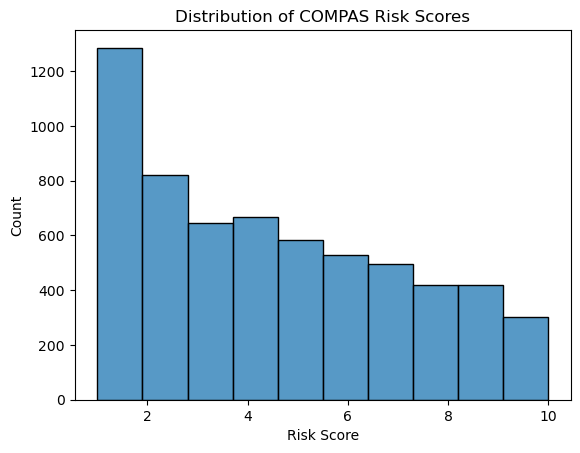

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(compas_clean['decile_score'], bins=10)

plt.title("Distribution of COMPAS Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

**Insight:**

The distribution of COMPAS scores shows how individuals are categorized across risk levels.

A balanced distribution suggests the model differentiates between individuals, while clustering at higher scores may indicate harsher risk assessments.

This provides a baseline understanding before comparing across demographic groups.

---

### Risk Score by Race

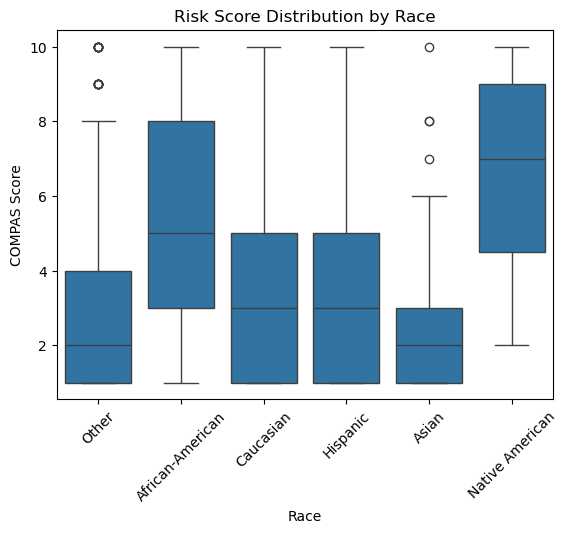

In [5]:
plt.figure()
sns.boxplot(x='race', y='decile_score', data=compas_clean)

plt.title("Risk Score Distribution by Race")
plt.xlabel("Race")
plt.ylabel("COMPAS Score")
plt.xticks(rotation=45)
plt.show()

**Insight:**

There are visible differences in risk score distributions across racial groups.

Some groups show higher median risk scores and wider variability, suggesting that the model may assign higher risk levels disproportionately.

This does not yet prove bias, but it raises an important question:
Are these differences due to underlying factors, or does the model systematically treat groups differently?

This indicates the need for deeper fairness analysis in the next sections.

-----

## Recidivism Rate by Race

In [6]:
compas_clean.groupby('race')['two_year_recid'].mean().sort_values()

race
Asian               0.258065
Other               0.361516
Hispanic            0.371316
Caucasian           0.390870
Native American     0.454545
African-American    0.523150
Name: two_year_recid, dtype: float64

**Insight:**

The actual recidivism rates across groups provide a benchmark for evaluating fairness.

If risk scores differ significantly more than actual recidivism rates, this suggests the model may be overestimating risk for certain groups.

Comparing predicted risk (scores) vs actual outcomes is critical for identifying bias in decision-making systems.

---
---

## Error Analysis: False Positives & False Negatives

**Purpose:** Evaluate whether COMPAS prediction errors differ across demographic groups.

Rather than only comparing risk scores, I analyze **prediction errors** to determine fairness.

We focus on:
- **False Positives:** Predicted high risk but did NOT reoffend
- **False Negatives:** Predicted low risk but DID reoffend

A fair system should have similar error rates across groups.

Differences in these rates may indicate bias in how the model treats individuals.

### High Risk Prediction

In [7]:
compas_clean['predicted_high_risk'] = compas_clean['decile_score'] >= 5

### Actual outcome

In [8]:
compas_clean['actual_recid'] = compas_clean['two_year_recid'] == 1

### Define Errors

In [9]:
# False Positive: predicted high risk BUT did NOT reoffend
compas_clean['false_positive'] = (
    (compas_clean['predicted_high_risk'] == True) &
    (compas_clean['actual_recid'] == False)
)

# False Negative: predicted low risk BUT DID reoffend
compas_clean['false_negative'] = (
    (compas_clean['predicted_high_risk'] == False) &
    (compas_clean['actual_recid'] == True)
)

### Error Rates by Race

In [10]:
fp_rates = compas_clean.groupby('race')['false_positive'].mean()
fn_rates = compas_clean.groupby('race')['false_negative'].mean()

fp_rates.sort_values(ascending=False), fn_rates.sort_values(ascending=False)

(race
 Native American     0.272727
 African-American    0.201890
 Caucasian           0.134094
 Hispanic            0.121807
 Other               0.081633
 Asian               0.064516
 Name: false_positive, dtype: float64,
 race
 Other               0.239067
 Hispanic            0.216110
 Caucasian           0.194009
 African-American    0.148976
 Asian               0.096774
 Native American     0.000000
 Name: false_negative, dtype: float64)

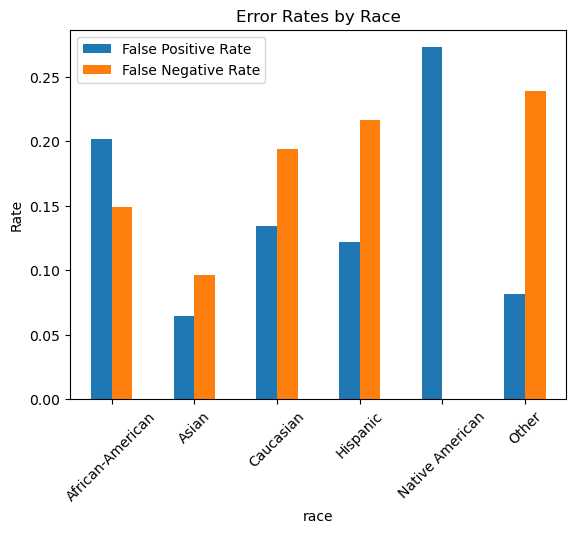

In [11]:
import pandas as pd

error_df = pd.DataFrame({
    'False Positive Rate': fp_rates,
    'False Negative Rate': fn_rates
})

error_df.plot(kind='bar')
plt.title("Error Rates by Race")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.show()

**Insight:**

False positive and false negative rates differ across racial groups, indicating that the COMPAS model does not make errors uniformly.

Higher false positive rates for certain groups suggest that individuals are more likely to be incorrectly labeled as high risk despite not reoffending.

At the same time, differences in false negative rates indicate that some groups are more likely to be underestimated in risk.

This imbalance highlights a key fairness issue:
Even if overall accuracy appears acceptable, the **distribution of errors is unequal**, which can lead to systematically unfair outcomes in real world decision making circumstances.

This result provides strong evidence that the model may exhibit bias across demographic groups.

---
---

## Fairness Interpretation & Conclusion

**Purpose:** Synthesize findings from the analysis to evaluate whether the COMPAS model demonstrates fairness across demographic groups.

In this section, I interpret patterns observed in risk scores, recidivism rates, and prediction errors to determine whether the model treats individuals equitably.

I move beyond raw metrics to assess the real-world implications of algorithmic decision-making.

------

**Final Insight:**

The analysis reveals that COMPAS risk scores and prediction errors are not evenly distributed across racial groups.

While differences in recidivism rates exist, the variation in risk scores and error rates suggests that the model does not treat all groups equally. In particular, higher false positive rates for certain groups indicate that individuals may be disproportionately labeled as high risk despite not reoffending.

This imbalance is critical because false positives can lead to more serious outcomes, such as longer sentences or denied parole, based on incorrect risk assessments.

At the same time, differences in false negative rates show that the model may underestimate risk for other groups, creating an uneven distribution of predictive accuracy.

These findings highlight a key limitation of algorithmic decision-making systems:
Even when models appear statistically accurate overall, unequal error distributions can produce systematically unfair outcomes.

This case study demonstrates the importance of evaluating not only model performance, but also fairness,  particularly in high stakes domains such as criminal justice.